In [1]:
%pip cache purge
%pip install -r ../requirements.txt


Files removed: 0 (0 bytes)
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://pypi.python.org/simple
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

import os
import shutil
import random

import warnings
from time import time
import seaborn as sns
sns.set(rc={'figure.figsize':(12,8)})

# mne import
import mne
from mne import Epochs, pick_types, events_from_annotations
from mne.io import concatenate_raws
from mne.io.edf import read_raw_edf
from mne.datasets import eegbci
from mne.preprocessing import (ICA, create_eog_epochs, create_ecg_epochs, corrmap, Xdawn)
from mne.time_frequency import AverageTFR
from mne.channels import make_standard_montage
from mne.decoding import LinearModel, Vectorizer, get_coef, Scaler, CSP, SPoC, UnsupervisedSpatialFilter
# from mne.time_frequency import psd_welch
mne.set_log_level('WARNING')

import sklearn
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.model_selection import ShuffleSplit, cross_val_score
from sklearn.decomposition import PCA, FastICA
from sklearn.preprocessing import FunctionTransformer, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn import datasets
from sklearn.model_selection import train_test_split


In [3]:
DIRECTORIES = [
    "../models", 
    # "../data/raw/files",
	"../plots",
]
deleted_files = []

for directory in DIRECTORIES:
    if not os.path.exists(directory):
        print(f"Directory '{directory}' does not exist.")
        continue

    for item in os.listdir(directory):
        item_path = os.path.join(directory, item)

        if item == ".gitkeep":
            continue  # Skip .gitkeep

        if os.path.isfile(item_path):
            os.remove(item_path)
            deleted_files.append(item_path)
        elif os.path.isdir(item_path):
            shutil.rmtree(item_path)
            deleted_files.append(item_path + "/")  

if deleted_files:
    print("Deleted files and directories:")
    for file in deleted_files:
        print(f" - {file}")
else:
    print("No files to delete.")


No files to delete.


In [4]:
subjects = random.sample(range(1, 110), 8)  # 8 random and unique subjects
subjects.sort()

experiments = [
    [3, 7, 11],
    [4, 8, 12],
    [5, 9, 13],
    [6, 10, 14]
]
run_experiments = random.choice(experiments)

# subjects = [1, 2, 3]
# run_experiments = [5, 9, 13]

print(f"Subjects: {subjects}")
print(f"Experiments: {run_experiments}")


Subjects: [3, 20, 36, 38, 52, 60, 74, 103]
Experiments: [3, 7, 11]


In [5]:
raw_files = []

for person_number in subjects:
    for i in run_experiments:
        raw_files_experiments = [read_raw_edf(f, preload=True, stim_channel='auto') for f in eegbci.load_data(person_number, i)]
        
        raw_experiments = concatenate_raws(raw_files_experiments)

        events, _ = mne.events_from_annotations(raw_experiments, event_id=dict(T0=1,T1=2,T2=3))
        mapping = {1:'rest', 2: 'action_1', 3: 'action_2'}
        annot_from_events = mne.annotations_from_events(
            events=events, event_desc=mapping, sfreq=raw_experiments.info['sfreq'],
            orig_time=raw_experiments.info['meas_date'])
        raw_experiments.set_annotations(annot_from_events)
        
        raw_files.append(raw_experiments)


In [6]:
raw_files


[<RawEDF | S003R03.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>,
 <RawEDF | S003R07.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>,
 <RawEDF | S003R11.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>,
 <RawEDF | S020R03.edf, 64 x 19680 (123.0 s), ~9.7 MiB, data loaded>,
 <RawEDF | S020R07.edf, 64 x 19680 (123.0 s), ~9.7 MiB, data loaded>,
 <RawEDF | S020R11.edf, 64 x 19680 (123.0 s), ~9.7 MiB, data loaded>,
 <RawEDF | S036R03.edf, 64 x 19680 (123.0 s), ~9.7 MiB, data loaded>,
 <RawEDF | S036R07.edf, 64 x 19680 (123.0 s), ~9.7 MiB, data loaded>,
 <RawEDF | S036R11.edf, 64 x 19680 (123.0 s), ~9.7 MiB, data loaded>,
 <RawEDF | S038R03.edf, 64 x 19680 (123.0 s), ~9.7 MiB, data loaded>,
 <RawEDF | S038R07.edf, 64 x 19680 (123.0 s), ~9.7 MiB, data loaded>,
 <RawEDF | S038R11.edf, 64 x 19680 (123.0 s), ~9.7 MiB, data loaded>,
 <RawEDF | S052R03.edf, 64 x 19680 (123.0 s), ~9.7 MiB, data loaded>,
 <RawEDF | S052R07.edf, 64 x 19680 (123.0 s), ~9.7 MiB, data loaded>,
 <RawEDF | S052R11.e

In [7]:
raw = concatenate_raws(raw_files)
events, event_dict = mne.events_from_annotations(raw)
print(raw.info)
print(event_dict)


<Info | 8 non-empty values
 bads: []
 ch_names: Fc5., Fc3., Fc1., Fcz., Fc2., Fc4., Fc6., C5.., C3.., C1.., ...
 chs: 64 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>
{'action_1': 1, 'action_2': 2, 'rest': 3}


In [8]:
picks = pick_types(raw.info, meg=False, eeg=True, stim=False, eog=False, exclude='bads')
print (picks)


[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63]


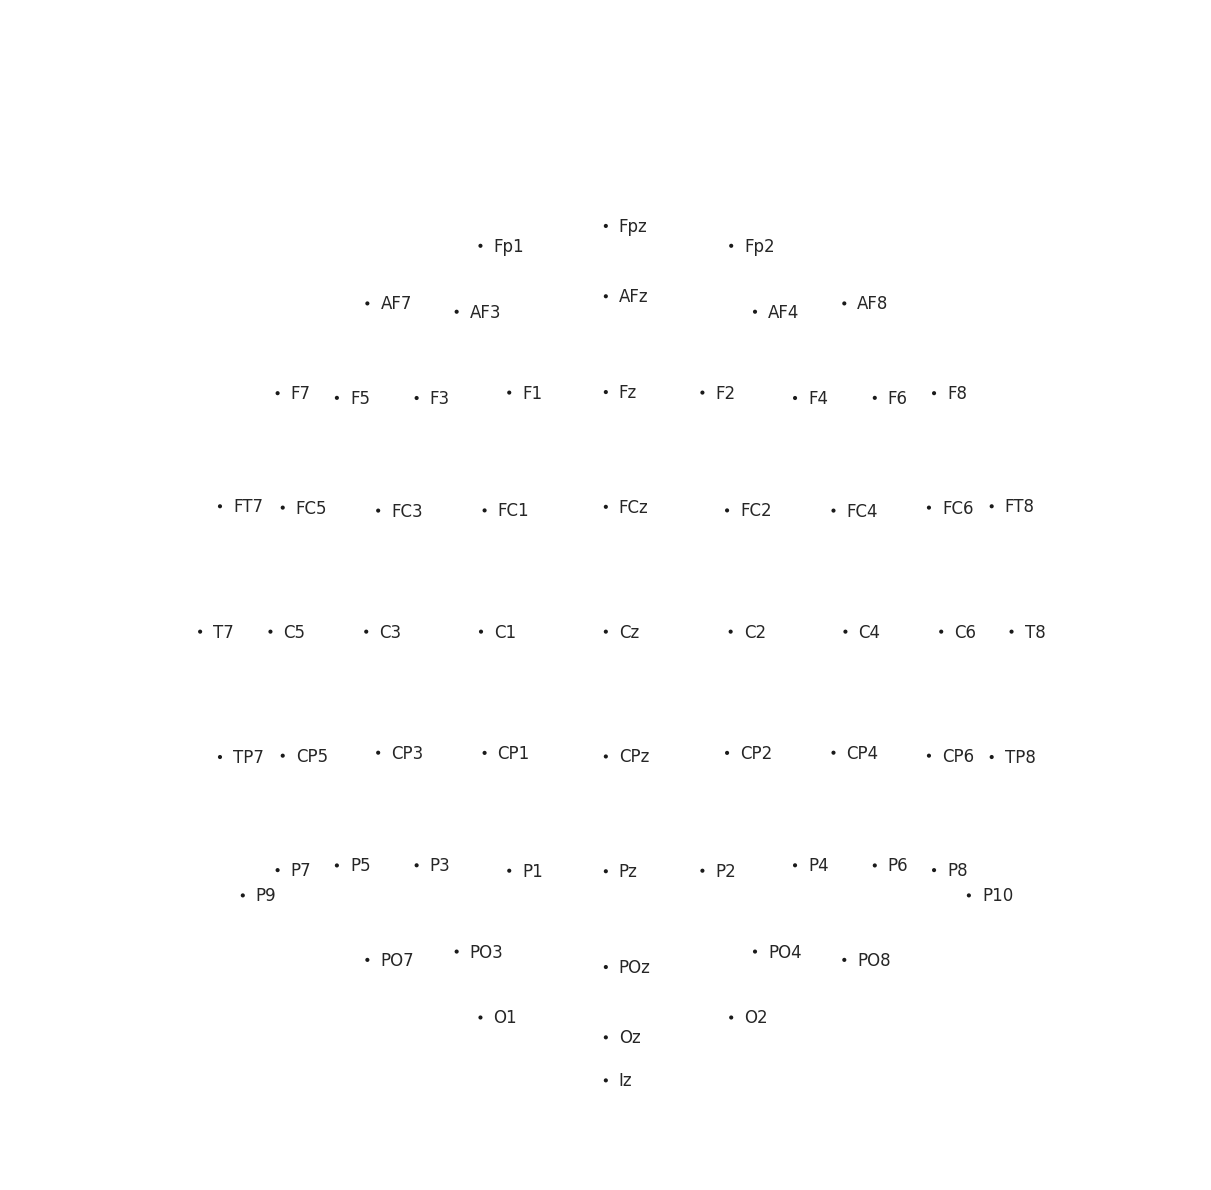

In [9]:
biosemi_montage = mne.channels.make_standard_montage('biosemi64')
biosemi_montage.plot()
plt.show()


In [10]:
eegbci.standardize(raw)  # set channel names
montage = make_standard_montage('standard_1005')
raw.set_montage(montage)


<RawEDF | S003R03.edf, 64 x 474240 (2964.0 s), ~231.6 MiB, data loaded>

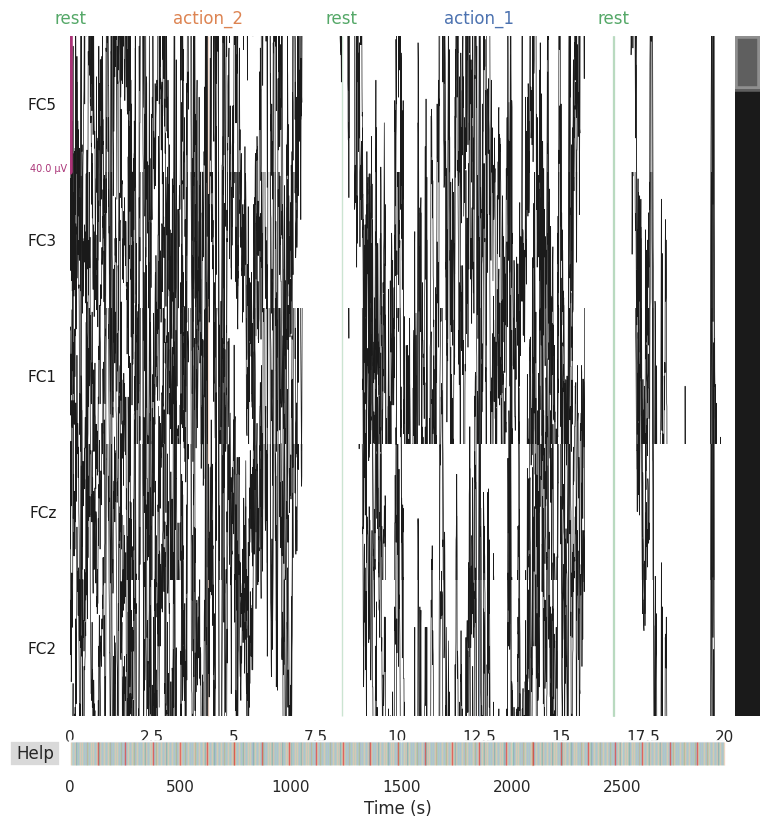

In [11]:
raw.plot(n_channels=5, duration = 20)
plt.show()


/sgoinfre/students/dgerwig-/miniforge/envs/vortex_env/lib/python3.11/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


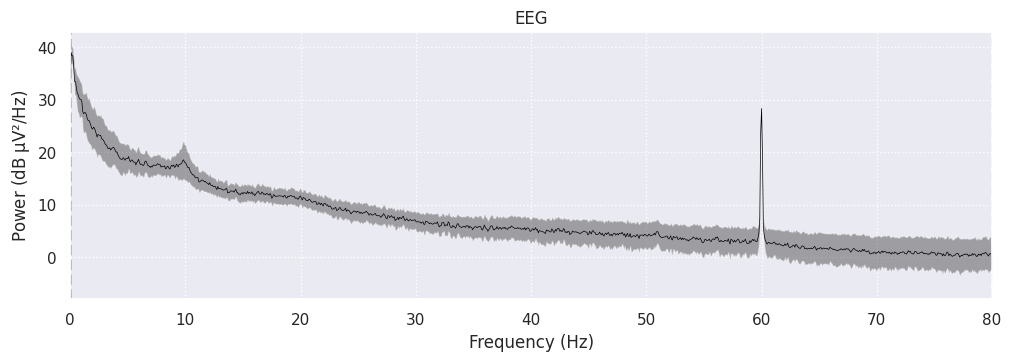

In [12]:
raw.plot_psd(average=True)
plt.show()


/sgoinfre/students/dgerwig-/miniforge/envs/vortex_env/lib/python3.11/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


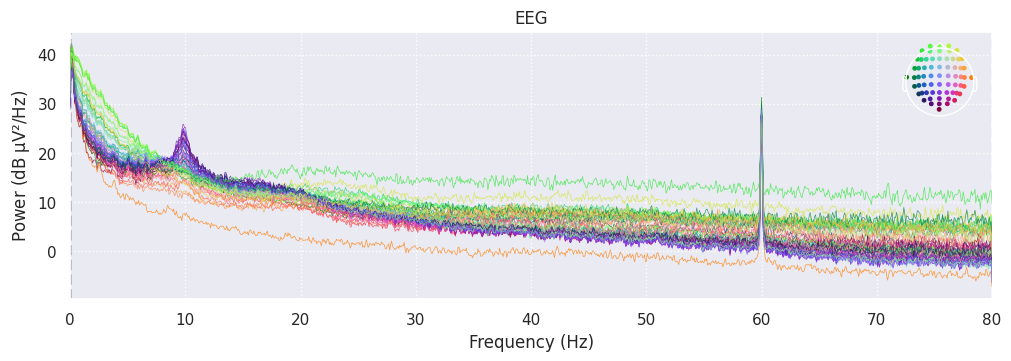

In [13]:
raw.plot_psd(average=False)
plt.show()


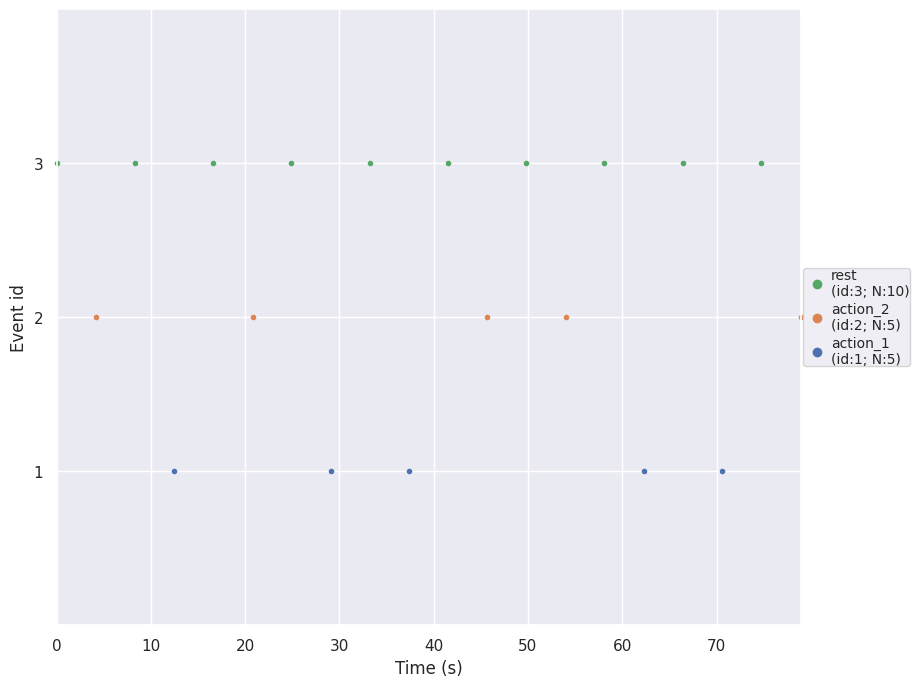

/tmp/ipykernel_2442289/4114355651.py:13: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(right=0.7)  # Hacer espacio para la leyenda


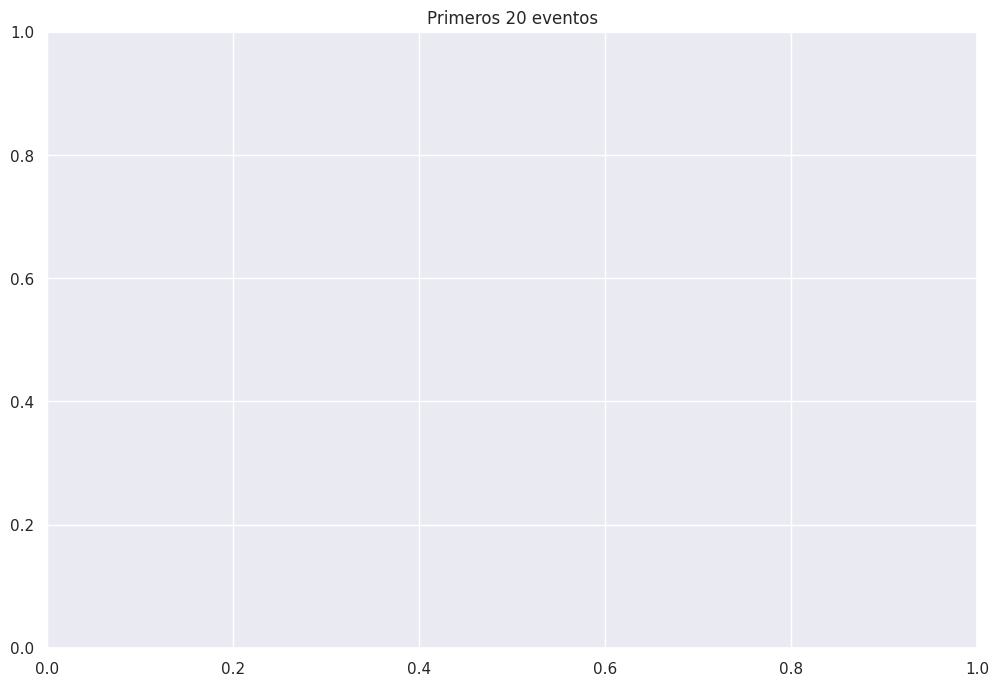

In [14]:
# Visualizar los primeros eventos
eventos_limitados = events[:30]  # Toma solo los primeros eventos

fig = mne.viz.plot_events(eventos_limitados, 
                         sfreq=raw.info['sfreq'],
                         first_samp=raw.first_samp, 
                         event_id=event_dict)
fig.subplots_adjust(right=0.7)  # Hacer espacio para la leyenda


In [15]:
raw.filter(8., 40., fir_design='firwin', skip_by_annotation='edge')


<RawEDF | S003R03.edf, 64 x 474240 (2964.0 s), ~231.6 MiB, data loaded>

/sgoinfre/students/dgerwig-/miniforge/envs/vortex_env/lib/python3.11/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


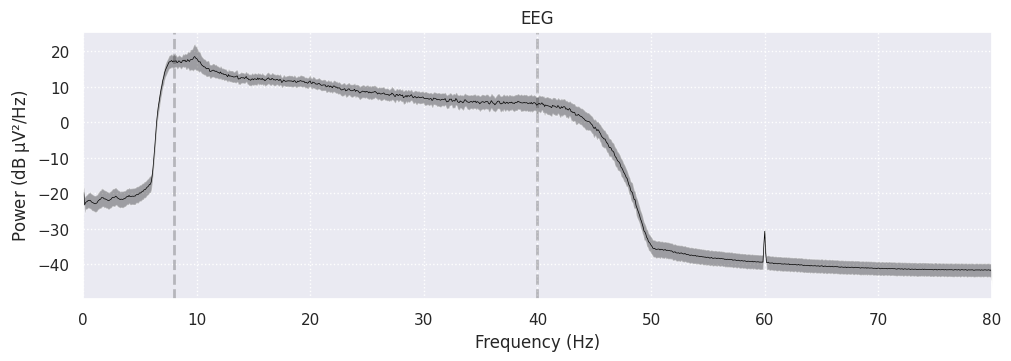

In [16]:
raw.plot_psd(average=True)
plt.show()


/sgoinfre/students/dgerwig-/miniforge/envs/vortex_env/lib/python3.11/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


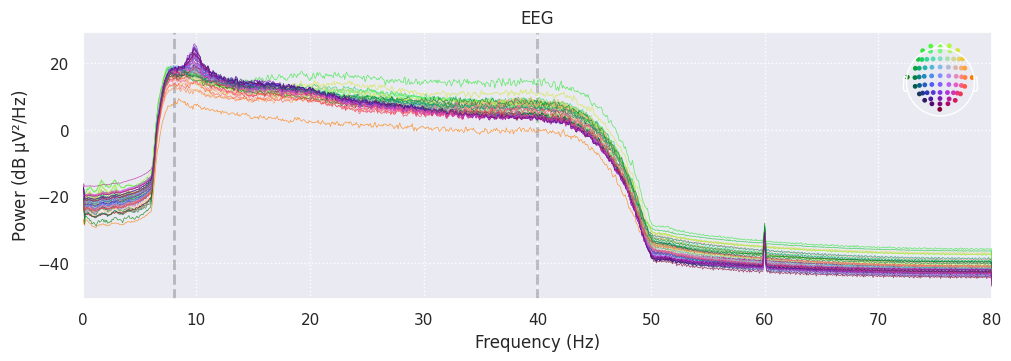

In [17]:
raw.plot_psd(average=False)
plt.show()


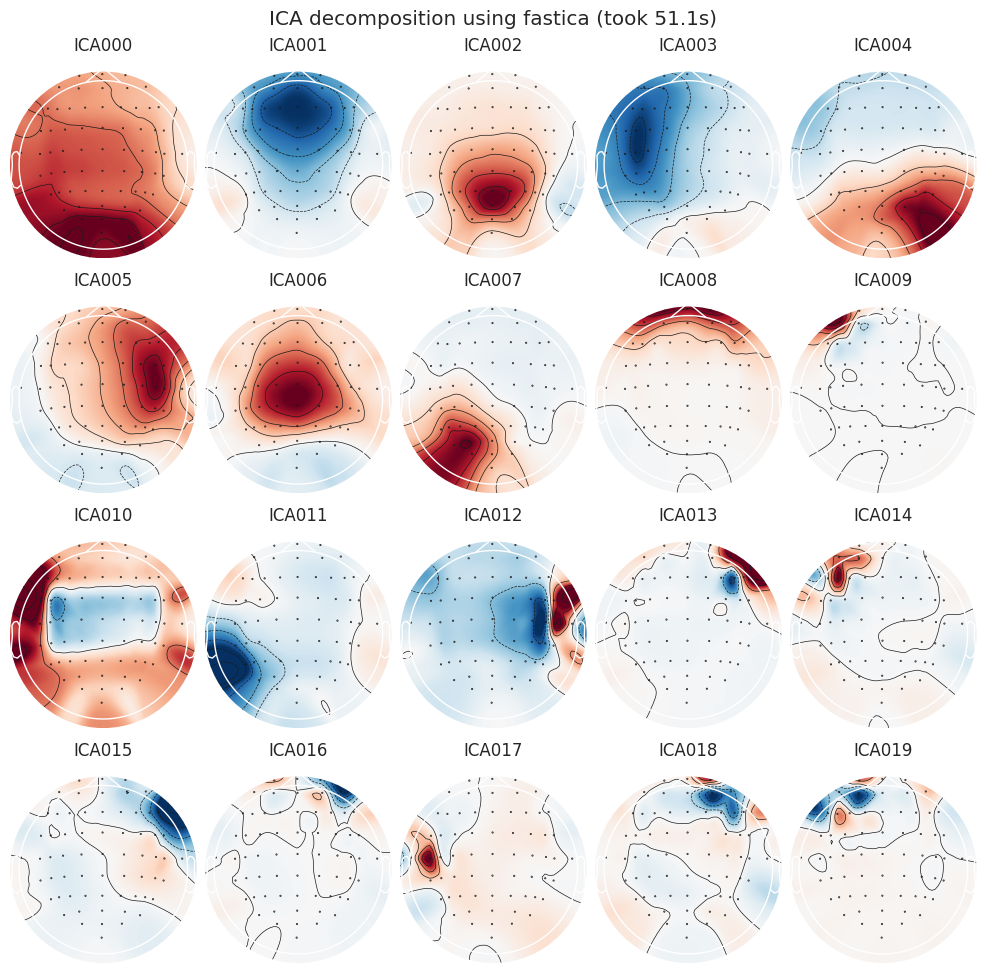

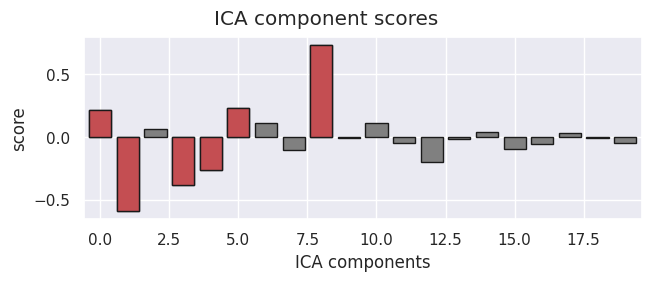

[8, 1, 3, 4, 5, 0] {'eog/0/Fpz': [0, 1, 3, 4, 5, 8], 'eog': [8, 1, 3, 4, 5, 0]}


In [18]:
def run_ica(raw, method, fit_params=None):
    raw_corrected = raw.copy()
    n_components=20
    
    ica = ICA(n_components=n_components, method=method, fit_params=fit_params, random_state=97)
    t0 = time()
    ica.fit(raw_corrected, picks=picks)
    fit_time = time() - t0
    title = ('ICA decomposition using %s (took %.1fs)' % (method, fit_time))
    ica.plot_components(title=title)
    plt.show()
    
    eog_indices, scores = ica.find_bads_eog(raw, ch_name='Fpz',threshold=1.5)
    ica.plot_scores(scores, exclude=eog_indices)  # look at r scores of components
    ica.exclude.extend(eog_indices) 
    raw_corrected = ica.apply(raw_corrected, n_pca_components = n_components, exclude = ica.exclude)
    print(ica.exclude, ica.labels_)
    return raw_corrected

raw_fastica = run_ica(raw, 'fastica')


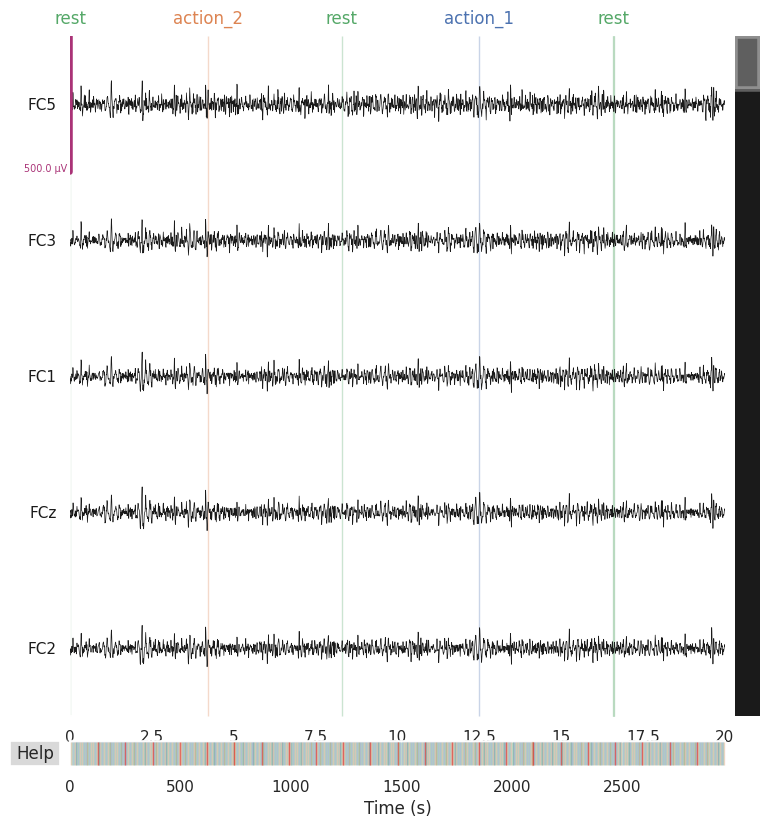

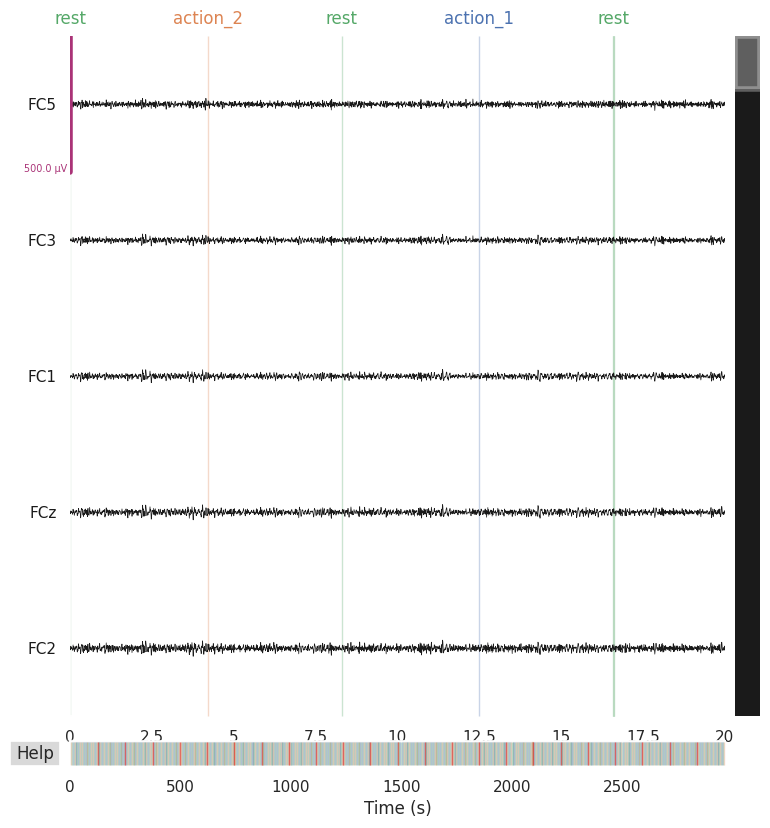

In [19]:
raw.plot(n_channels=5, start=0, duration=20,scalings=dict(eeg=250e-6))
raw_fastica.plot(n_channels=5, start=0, duration=20,scalings=dict(eeg=250e-6))
plt.show()


In [20]:
# event_id = {'do/feet': 1, 'do/hands': 2, 'imagine/feet': 3, 'imagine/hands': 4}
event_id = {'action_1': 1, 'action_2': 2}


In [21]:
tmin, tmax = -1., 4.

events, event_dict = mne.events_from_annotations(raw, event_id=event_id)
# events, event_dict = mne.events_from_annotations(raw_fastica, event_id=event_id)
print (event_dict)


{'action_1': 1, 'action_2': 2}


In [22]:
picks


array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63])

In [23]:
epochs = Epochs(raw, events, event_id, tmin, tmax, proj=True, picks=picks, baseline=None, preload=True)
# epochs = Epochs(raw_fastica, events, event_id, tmin, tmax, proj=True, picks=picks, baseline=None, preload=True)
epochs


<Epochs | 357 events (all good), -1 – 4 s (baseline off), ~139.7 MiB, data loaded,
 'action_1': 178
 'action_2': 179>

In [24]:
labels = epochs.events[:, -1] - 1
labels


array([1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1,
       0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0,
       0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1,
       0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0,
       1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0,
       1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0,
       0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0,
       1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0,

# PIPELINE

Shape of epochs_data: (357, 64, 801)
No existing score_pipeline found, will create a new one.
Testing CSP6 + LDA...
CSP6 + LDA - Accuracy: 0.4861 (± 0.0527)
  Individual fold scores: [0.45833333 0.52777778 0.48611111 0.5        0.45833333]
Testing CSP6 + LogReg...
CSP6 + LogReg - Accuracy: 0.4861 (± 0.0248)
  Individual fold scores: [0.48611111 0.5        0.47222222 0.5        0.47222222]
Testing CSP6 + RF...
CSP6 + RF - Accuracy: 0.5278 (± 0.1639)
  Individual fold scores: [0.43055556 0.65277778 0.55555556 0.55555556 0.44444444]
Testing CSP6 + MLP...
CSP6 + MLP - Accuracy: 0.4778 (± 0.0515)
  Individual fold scores: [0.5        0.47222222 0.5        0.48611111 0.43055556]
Testing CSP8 + LDA...
CSP8 + LDA - Accuracy: 0.5167 (± 0.1184)
  Individual fold scores: [0.5        0.43055556 0.48611111 0.58333333 0.58333333]
Testing CSP8 + LogReg...
CSP8 + LogReg - Accuracy: 0.4972 (± 0.0509)
  Individual fold scores: [0.47222222 0.47222222 0.48611111 0.52777778 0.52777778]
Testing CSP8 + RF...

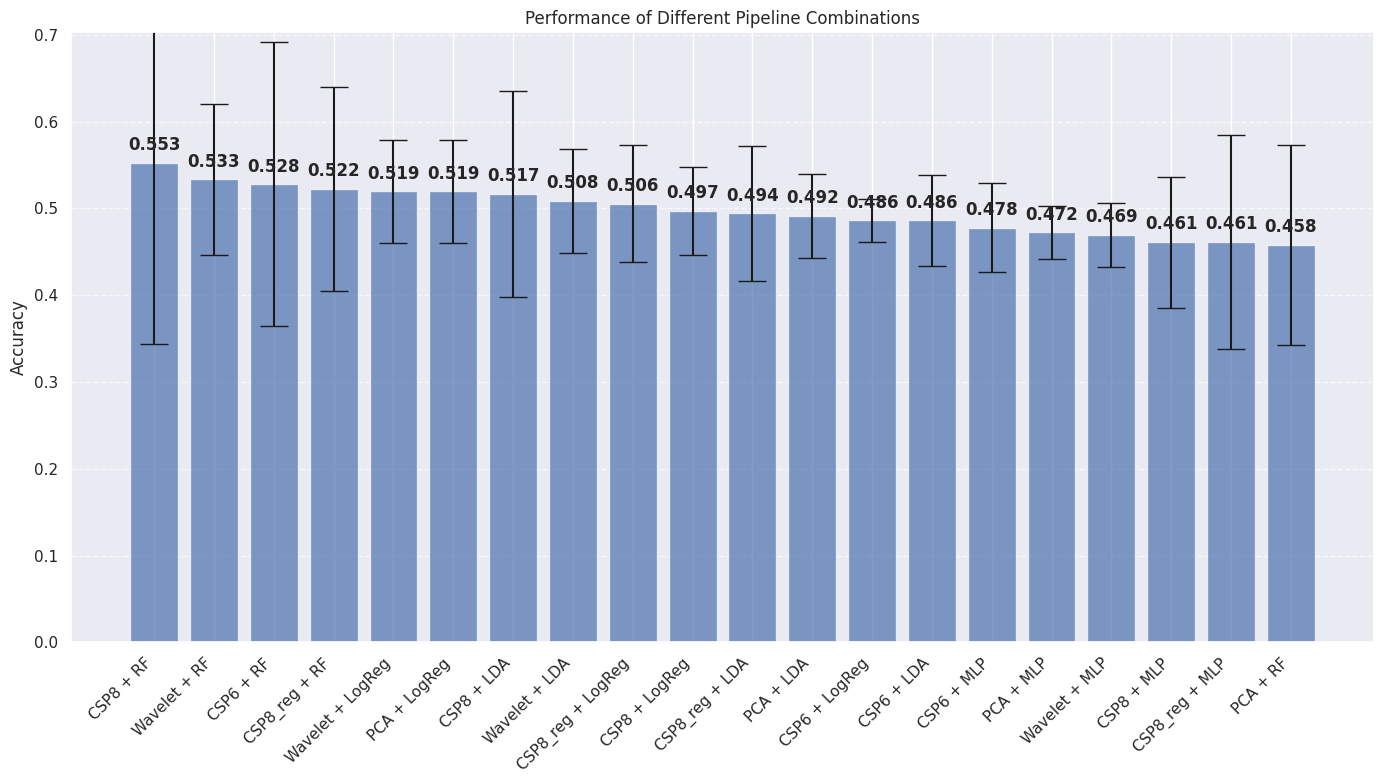

/tmp/ipykernel_2442289/3456427687.py:365: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=labels_to_plot)


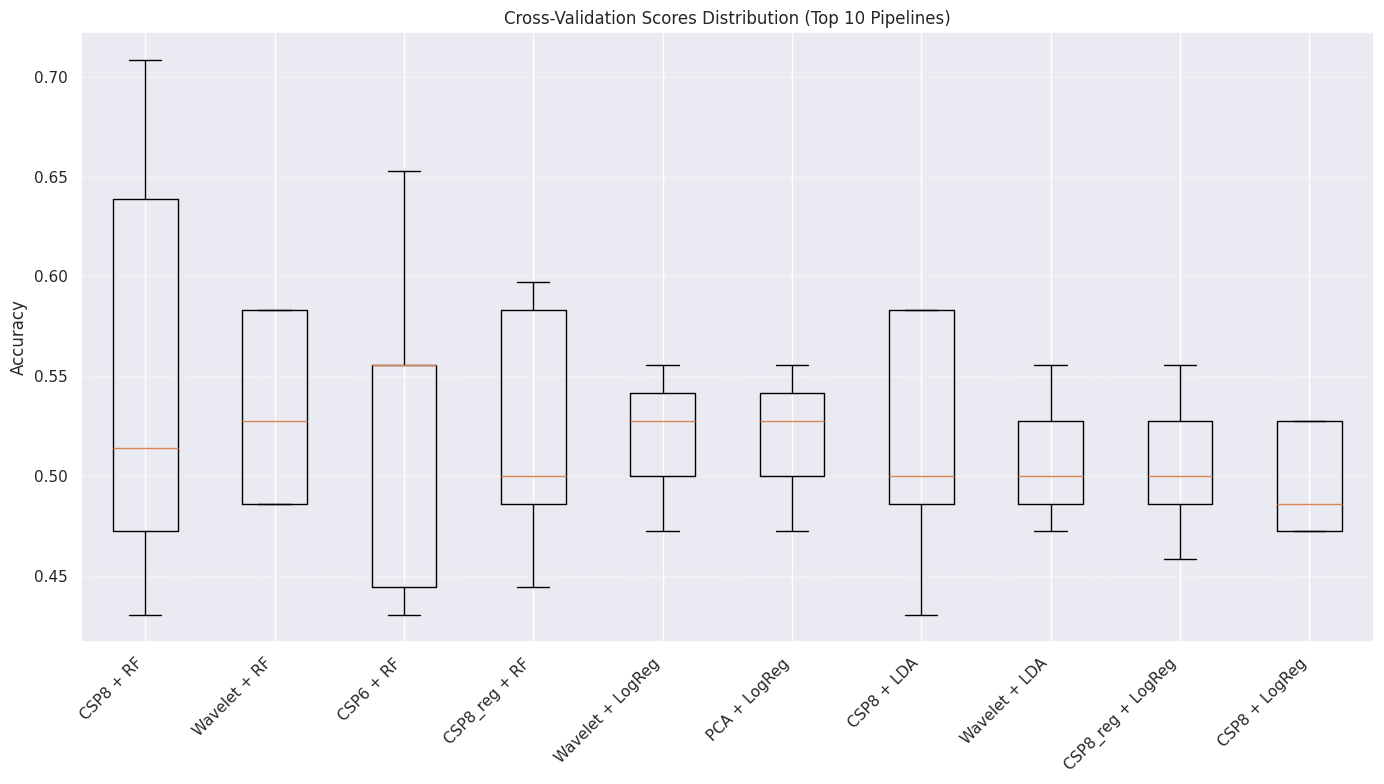

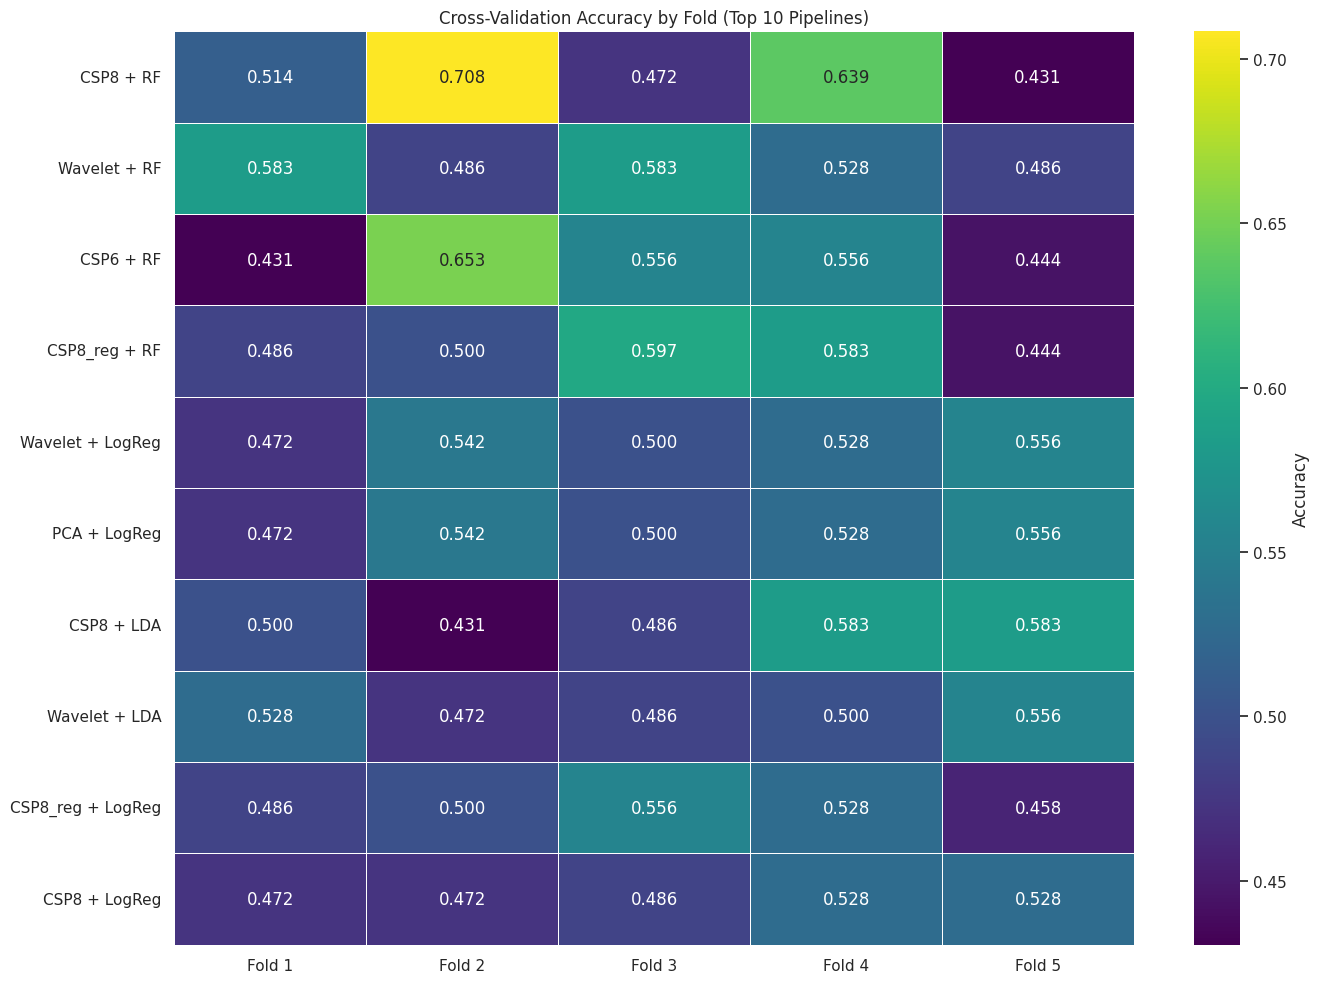

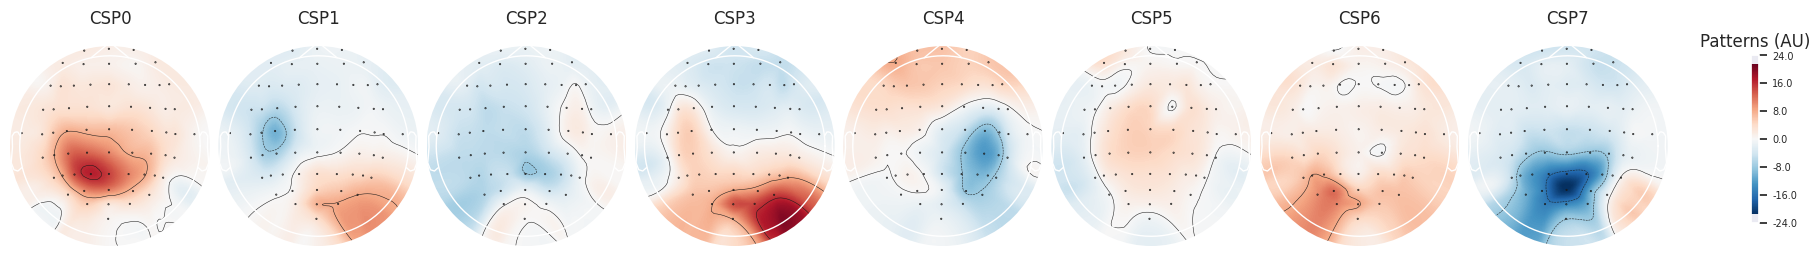


Performing simplified hyperparameter optimization for RandomForest...
Testing 8 parameter combinations...
Progress: 1/8 - Parameters: n_est=50, max_depth=None, class_weight=balanced - Accuracy: 0.5361 ± 0.2444
Progress: 2/8 - Parameters: n_est=50, max_depth=None, class_weight=None - Accuracy: 0.5417 ± 0.1521
Progress: 3/8 - Parameters: n_est=50, max_depth=15, class_weight=balanced - Accuracy: 0.5361 ± 0.2315
Progress: 4/8 - Parameters: n_est=50, max_depth=15, class_weight=None - Accuracy: 0.5417 ± 0.1657
Progress: 5/8 - Parameters: n_est=100, max_depth=None, class_weight=balanced - Accuracy: 0.5528 ± 0.2089
Progress: 6/8 - Parameters: n_est=100, max_depth=None, class_weight=None - Accuracy: 0.5361 ± 0.1856
Progress: 7/8 - Parameters: n_est=100, max_depth=15, class_weight=balanced - Accuracy: 0.5417 ± 0.2093
Progress: 8/8 - Parameters: n_est=100, max_depth=15, class_weight=None - Accuracy: 0.5361 ± 0.1937

Best parameters:
n_estimators: 100
max_depth: None
class_weight: balanced
Accura

/tmp/ipykernel_2442289/3456427687.py:620: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='n_estimators', y='mean_score', data=results_df,
/tmp/ipykernel_2442289/3456427687.py:620: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='n_estimators', y='mean_score', data=results_df,
/tmp/ipykernel_2442289/3456427687.py:628: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='max_depth', y='mean_score', data=results_df,
/tmp/ipykernel_2442289/3456427687.py:628: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='max_depth', y='mean_score', data=results_df,
/tmp/ipykernel_2442289/345

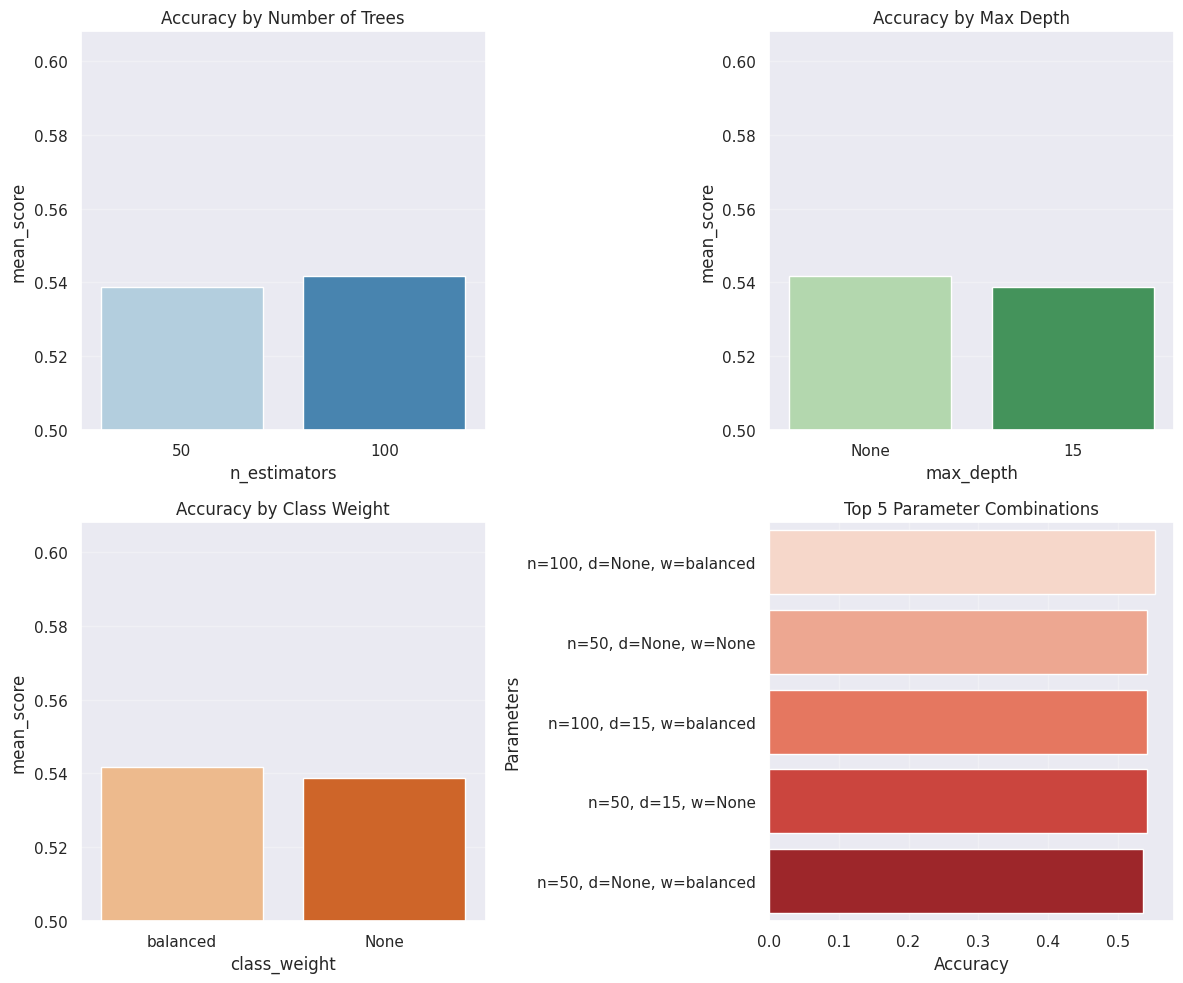


Example of subject-specific calibration function created. Use this function when processing new subjects.

Best model saved to: ../models/best_model_20250322_111835.joblib
Model information saved to: ../models/model_info_20250322_111835.joblib
Model information saved in JSON: ../models/model_info_20250322_111835.json


In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import ShuffleSplit, cross_val_score, cross_validate, GridSearchCV, train_test_split
from sklearn.decomposition import PCA
from mne.decoding import CSP
from mne.filter import filter_data  # Using MNE's filter_data instead
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd
import seaborn as sns
from sklearn.model_selection import learning_curve
from sklearn.metrics import make_scorer, accuracy_score
from sklearn.model_selection import validation_curve
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.feature_selection import SelectFromModel
import os
import joblib
from datetime import datetime
import json

# Use existing epochs data
epochs_data = epochs.get_data().astype(np.float64)

# Verify data shape
print(f"Shape of epochs_data: {epochs_data.shape}")
# Should be (n_epochs, n_channels, n_timepoints)

# Custom transformer to reshape 3D data to 2D for PCA
class Reshaper(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.original_shape = None
        
    def fit(self, X, y=None):
        self.original_shape = X.shape
        return self
        
    def transform(self, X):
        # Reshape from (n_epochs, n_channels, n_timepoints) to (n_epochs, n_channels*n_timepoints)
        n_epochs = X.shape[0]
        return X.reshape(n_epochs, -1)
    
    def fit_transform(self, X, y=None):
        return self.fit(X, y).transform(X)

# Wavelet transformer for DWT
class WaveletTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, wavelet='db4', level=5, feature_mode='mean_var'):
        self.wavelet = wavelet
        self.level = level
        self.feature_mode = feature_mode
        
    def fit(self, X, y=None):
        return self
        
    def transform(self, X):
        import pywt
        
        n_epochs, n_channels, n_times = X.shape
        features = []
        
        for epoch_idx in range(n_epochs):
            epoch_features = []
            
            for ch_idx in range(n_channels):
                # Apply DWT
                coeffs = pywt.wavedec(X[epoch_idx, ch_idx], self.wavelet, level=self.level)
                
                # Extract features based on selected mode
                if self.feature_mode == 'concat':
                    # Concatenate all coefficients (can result in very high dimensions)
                    ch_features = np.concatenate([coef.flatten() for coef in coeffs])
                elif self.feature_mode == 'mean_var':
                    # Calculate mean and variance per level (more compact features)
                    ch_features = []
                    for coef in coeffs:
                        ch_features.extend([np.mean(coef), np.var(coef)])
                elif self.feature_mode == 'energy':
                    # Calculate energy per band
                    ch_features = [np.sum(np.square(c)) for c in coeffs]
                
                epoch_features.extend(ch_features)
            
            features.append(epoch_features)
        
        return np.array(features)
    
    def fit_transform(self, X, y=None):
        return self.fit(X, y).transform(X)

# Create a custom filter transformer instead of using FilterEstimator
class FrequencyFilterTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, sfreq=160, l_freq=None, h_freq=None):
        self.sfreq = sfreq
        self.l_freq = l_freq
        self.h_freq = h_freq
        
    def fit(self, X, y=None):
        return self
        
    def transform(self, X):
        n_epochs, n_channels, n_times = X.shape
        X_filtered = np.zeros_like(X)
        
        for i in range(n_epochs):
            X_filtered[i] = filter_data(X[i], self.sfreq, self.l_freq, self.h_freq, verbose=False)
            
        return X_filtered
    
    def fit_transform(self, X, y=None):
        return self.fit(X, y).transform(X)

# Define improved feature extractors
feature_extractors = {
    'CSP6': CSP(n_components=6, reg=None, log=True, norm_trace=False, cov_est='concat'),
    'CSP8': CSP(n_components=8, reg=None, log=True, norm_trace=False, cov_est='concat'),
    'CSP8_reg': CSP(n_components=6, reg=0.1, log=True, norm_trace=False, cov_est='concat'),
    'PCA': make_pipeline(Reshaper(), PCA(n_components=15)),  
    'Wavelet': WaveletTransformer(wavelet='db4', level=4, feature_mode='mean_var')
}

# Define classifiers with balanced class weights
classifiers = {
    'LDA': LinearDiscriminantAnalysis(solver='svd'),
    'LogReg': LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced', random_state=42),
    'RF': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'MLP': MLPClassifier(
        hidden_layer_sizes=(100,50),
        activation='relu',
        solver='adam',
        alpha=0.0001,
        batch_size='auto',
        learning_rate='adaptive',
        max_iter=1000,
        random_state=42,
        validation_fraction=0.2,  
        early_stopping=True,
        n_iter_no_change=10
    )
}

# # Add frequency band-specific extractors
# bands = {
#     'alpha': (8, 13),
#     'beta': (13, 30),
#     'both': (8, 30)
# }

# for band_name, (low, high) in bands.items():
#     feature_extractors[f'Filter_{band_name}'] = make_pipeline(
#         FrequencyFilterTransformer(sfreq=160, l_freq=low, h_freq=high),
#         CSP(n_components=6, reg=None, log=True)
#     )

# Define cross-validation strategy
cv = ShuffleSplit(5, test_size=0.2, random_state=42)

# Store results
results = {}
cv_results_detailed = {}
best_score = 0
best_pipeline = None

# Try to get current best performance if it exists
score_pipeline_current = -1
try:
    score_pipeline_current = score_pipeline
except NameError:
    print("No existing score_pipeline found, will create a new one.")

# Test all combinations
for feat_name, feat_transformer in feature_extractors.items():
    for clf_name, classifier in classifiers.items():
        combo_name = f"{feat_name} + {clf_name}"
        print(f"Testing {combo_name}...")
        
        # Create pipeline
        pipeline = make_pipeline(feat_transformer, classifier)
        
        try:
            # Use cross_validate instead of cross_val_score for more metrics
            cv_results = cross_validate(
                pipeline, 
                epochs_data, 
                labels, 
                cv=cv, 
                n_jobs=1,
                return_train_score=True,
                scoring='accuracy'
            )
            
            # Store detailed results
            cv_results_detailed[combo_name] = cv_results
            
            # Calculate statistics
            test_scores = cv_results['test_score']
            
            # Store results
            results[combo_name] = {
                'mean': test_scores.mean(), 
                'std': test_scores.std(),
                'pipeline': pipeline,
                'fold_scores': test_scores
            }
            
            # Check if this is the best pipeline so far
            if test_scores.mean() > best_score:
                best_score = test_scores.mean()
                best_pipeline = pipeline
            
            # Print results for this combination
            print(f"{combo_name} - Accuracy: {test_scores.mean():.4f} (± {test_scores.std() * 2:.4f})")
            print(f"  Individual fold scores: {test_scores}")
            
        except Exception as e:
            print(f"Error with {combo_name}: {str(e)}")
            continue

# # Try ensemble approach
# try:
#     print("\nTesting ensemble approaches...")
    
#     # Get the best CSP configuration
#     best_csp_name = None
#     best_csp_score = 0
    
#     for name, result in results.items():
#         if 'CSP' in name and result['mean'] > best_csp_score:
#             best_csp_score = result['mean']
#             best_csp_name = name
    
#     if best_csp_name:
#         csp_name = best_csp_name.split(' + ')[0]
#         csp = feature_extractors[csp_name]
        
#         # Create ensemble of different classifiers with the best CSP
#         ensemble = VotingClassifier(
#             estimators=[
#                 ('rf', make_pipeline(csp, RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42))),
#                 ('lda', make_pipeline(csp, LinearDiscriminantAnalysis(solver='svd'))),
#                 ('logistic', make_pipeline(csp, LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced', random_state=42)))
#             ],
#             voting='soft'  # Use probability estimates
#         )
        
#         # Evaluate ensemble
#         ensemble_cv = cross_validate(ensemble, epochs_data, labels, cv=cv, 
#                                    scoring='accuracy', return_train_score=True)
#         ensemble_scores = ensemble_cv['test_score']
        
#         # Store results
#         combo_name = f"{csp_name} + Ensemble"
#         results[combo_name] = {
#             'mean': ensemble_scores.mean(), 
#             'std': ensemble_scores.std(),
#             'pipeline': ensemble,
#             'fold_scores': ensemble_scores
#         }
        
#         print(f"{combo_name} - Accuracy: {ensemble_scores.mean():.4f} (± {ensemble_scores.std() * 2:.4f})")
#         print(f"  Individual fold scores: {ensemble_scores}")
        
#         # Check if this is the best pipeline
#         if ensemble_scores.mean() > best_score:
#             best_score = ensemble_scores.mean()
#             best_pipeline = ensemble
    
# except Exception as e:
#     print(f"Error with ensemble approach: {str(e)}")

# # Try feature selection with the best CSP and RF
# try:
#     print("\nTesting feature selection approach...")
    
#     # Get the best CSP configuration
#     best_csp_name = None
#     best_csp_score = 0
    
#     for name, result in results.items():
#         if 'CSP' in name and result['mean'] > best_csp_score:
#             best_csp_score = result['mean']
#             best_csp_name = name
    
#     if best_csp_name:
#         csp_name = best_csp_name.split(' + ')[0]
#         csp = feature_extractors[csp_name]
        
#         # Create pipeline with feature selection
#         feature_selection_pipeline = make_pipeline(
#             csp,
#             SelectFromModel(RandomForestClassifier(n_estimators=50, random_state=42)),
#             RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
#         )
        
#         # Evaluate
#         fs_cv = cross_validate(feature_selection_pipeline, epochs_data, labels, cv=cv, 
#                              scoring='accuracy', return_train_score=True)
#         fs_scores = fs_cv['test_score']
        
#         # Store results
#         combo_name = f"{csp_name} + FeatureSelection + RF"
#         results[combo_name] = {
#             'mean': fs_scores.mean(), 
#             'std': fs_scores.std(),
#             'pipeline': feature_selection_pipeline,
#             'fold_scores': fs_scores
#         }
        
#         print(f"{combo_name} - Accuracy: {fs_scores.mean():.4f} (± {fs_scores.std() * 2:.4f})")
#         print(f"  Individual fold scores: {fs_scores}")
        
#         # Check if this is the best pipeline
#         if fs_scores.mean() > best_score:
#             best_score = fs_scores.mean()
#             best_pipeline = feature_selection_pipeline
    
# except Exception as e:
#     print(f"Error with feature selection approach: {str(e)}")

# Visualizations only if we have results
if results:
    # 1. Traditional bar chart (improved)
    plt.figure(figsize=(14, 8))
    combinations = list(results.keys())
    means = [results[combo]['mean'] for combo in combinations]
    stds = [results[combo]['std'] * 2 for combo in combinations]

    # Sort by performance
    sorted_indices = np.argsort(means)[::-1]  # Descending order
    sorted_combinations = [combinations[i] for i in sorted_indices]
    sorted_means = [means[i] for i in sorted_indices]
    sorted_stds = [stds[i] for i in sorted_indices]

    bars = plt.bar(sorted_combinations, sorted_means, yerr=sorted_stds, capsize=10, alpha=0.7)
    
    # Add value labels above bars
    for bar, value in zip(bars, sorted_means):
        plt.text(bar.get_x() + bar.get_width()/2, 
                bar.get_height() + 0.01, 
                f'{value:.3f}', 
                ha='center', va='bottom',
                fontweight='bold')
    
    plt.ylabel('Accuracy')
    plt.title('Performance of Different Pipeline Combinations')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, min(1.0, max(means) + 0.15))
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # 2. Detailed CV visualization - Boxplot
    plt.figure(figsize=(14, 8))
    data_to_plot = []
    labels_to_plot = []
    
    # Only show top 10 models for clarity
    for combo in sorted_combinations[:10]:
        data_to_plot.append(results[combo]['fold_scores'])
        labels_to_plot.append(combo)
    
    plt.boxplot(data_to_plot, labels=labels_to_plot)
    plt.title('Cross-Validation Scores Distribution (Top 10 Pipelines)')
    plt.ylabel('Accuracy')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
    
    # 3. Heatmap of scores by fold
    plt.figure(figsize=(14, 10))
    
    # Prepare data for heatmap - top 10 models
    heatmap_data = np.zeros((len(labels_to_plot), 5))  # 5 folds
    for i, combo in enumerate(labels_to_plot):
        heatmap_data[i] = results[combo]['fold_scores']
    
    # Create DataFrame for seaborn
    df_heatmap = pd.DataFrame(
        heatmap_data, 
        index=labels_to_plot,
        columns=[f'Fold {i+1}' for i in range(5)]
    )
    
    # Draw heatmap
    sns.heatmap(df_heatmap, annot=True, cmap='viridis', fmt='.3f',
                linewidths=.5, cbar_kws={'label': 'Accuracy'})
    plt.title('Cross-Validation Accuracy by Fold (Top 10 Pipelines)')
    plt.tight_layout()
    plt.show()
    
    # # 4. Advanced visualization: Training vs Testing
    # plt.figure(figsize=(14, 8))
    
    # # Only show top 5 models for clarity
    # for combo in sorted_combinations[:5]:
    #     cv_result = cv_results_detailed[combo]
    #     plt.plot(range(1, 6), cv_result['train_score'], 'o-', label=f'{combo} (Train)')
    #     plt.plot(range(1, 6), cv_result['test_score'], 's--', label=f'{combo} (Test)')
    
    # plt.xlabel('Fold')
    # plt.ylabel('Accuracy')
    # plt.title('Training vs Testing Accuracy by Fold (Top 5 Pipelines)')
    # plt.xticks(range(1, 6))
    # plt.grid(True, alpha=0.3)
    # plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    # plt.tight_layout()
    # plt.show()

    # # Print the best model
    # best_combo = max(results.items(), key=lambda x: x[1]['mean'])
    # print("\nBest combination:")
    # print(f"{best_combo[0]} - Accuracy: {best_combo[1]['mean']:.4f} (± {best_combo[1]['std'] * 2:.4f})")
    # print(f"Individual fold scores: {best_combo[1]['fold_scores']}")

    # # Update score_pipeline and models_pipeline if new best score is better
    # try:
    #     if best_score > score_pipeline_current:
    #         print(f"New best pipeline found! Accuracy: {best_score:.4f}")
    #         score_pipeline = best_score
    #         models_pipeline = best_pipeline
    #     else:
    #         print(f"No improvement over current best pipeline ({score_pipeline_current:.4f})")
    # except NameError:
    #     print("Creating new score_pipeline with value:", best_score)
    #     score_pipeline = best_score
    #     models_pipeline = best_pipeline

    # # 5. Learning curve for the best model
    # if best_pipeline is not None:
    #     # Calculate learning curve
    #     train_sizes = np.linspace(0.1, 1.0, 10)
    #     try:
    #         train_sizes, train_scores, test_scores = learning_curve(
    #             best_pipeline, epochs_data, labels, 
    #             train_sizes=train_sizes, cv=cv, 
    #             scoring='accuracy', n_jobs=1
    #         )
            
    #         # Calculate means and standard deviations
    #         train_mean = np.mean(train_scores, axis=1)
    #         train_std = np.std(train_scores, axis=1)
    #         test_mean = np.mean(test_scores, axis=1)
    #         test_std = np.std(test_scores, axis=1)
            
    #         # Plot learning curve
    #         plt.figure(figsize=(10, 6))
    #         plt.title(f'Learning Curve - {best_combo[0]}')
    #         plt.xlabel('Training Examples')
    #         plt.ylabel('Accuracy')
    #         plt.grid()
            
    #         plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
    #         plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')
    #         plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Score')
    #         plt.plot(train_sizes, test_mean, 'o-', color='orange', label='Cross-Validation Score')
            
    #         plt.legend(loc='best')
    #         plt.tight_layout()
    #         plt.show()
    #     except Exception as e:
    #         print(f"Error creating learning curve: {str(e)}")

    # If the best model uses CSP, visualize patterns
    best_combo = max(results.items(), key=lambda x: x[1]['mean'])
    best_combo_name = best_combo[0]

    if 'CSP' in best_combo_name:
        try:
            # Find the CSP step
            csp_found = False
            
            # First check if the pipeline has named_steps
            if hasattr(best_pipeline, 'named_steps'):
                # Look for the CSP step by name or type
                for step_name, step in best_pipeline.named_steps.items():
                    if isinstance(step, CSP):
                        csp = step
                        csp.fit_transform(epochs_data, labels)
                        csp.plot_patterns(epochs.info, ch_type='eeg', units='Patterns (AU)', size=1.5)
                        plt.show()
                        csp_found = True
                        break
                    
                    # CSP might be inside another pipeline step
                    if hasattr(step, 'named_steps'):
                        for sub_name, sub_step in step.named_steps.items():
                            if isinstance(sub_step, CSP):
                                csp = sub_step
                                csp.fit_transform(epochs_data, labels)
                                csp.plot_patterns(epochs.info, ch_type='eeg', units='Patterns (AU)', size=1.5)
                                plt.show()
                                csp_found = True
                                break
                
            if not csp_found:
                print("Could not find CSP step in pipeline to visualize patterns")
                
        except Exception as e:
            print(f"Error visualizing CSP patterns: {str(e)}")
    
    # 6. Simplified hyperparameter optimization for RandomForest
    best_combo = max(results.items(), key=lambda x: x[1]['mean'])
    best_combo_name = best_combo[0]

    if best_combo_name and 'RF' in best_combo_name:
        try:
            print("\nPerforming simplified hyperparameter optimization for RandomForest...")
            
            # Get feature extractor
            feat_name = best_combo_name.split(' + ')[0]
            feat_transformer = feature_extractors[feat_name]
            
            # Define a smaller parameter grid
            param_grid = {
                'randomforestclassifier__n_estimators': [50, 100],
                'randomforestclassifier__max_depth': [None, 15],
                'randomforestclassifier__class_weight': ['balanced', None]
            }
            
            # Calculate total number of combinations for progress tracking
            total_combinations = 1
            for param in param_grid.values():
                total_combinations *= len(param)
            
            print(f"Testing {total_combinations} parameter combinations...")
            
            # Create base pipeline
            base_pipeline = make_pipeline(
                feat_transformer,
                RandomForestClassifier(random_state=42)
            )
            
            # Store results for visualization
            param_results = []
            
            # Define a counter for progress tracking
            current_combination = 0
            
            # Manual grid search with progress tracking
            for n_est in param_grid['randomforestclassifier__n_estimators']:
                for max_depth in param_grid['randomforestclassifier__max_depth']:
                    for class_weight in param_grid['randomforestclassifier__class_weight']:
                        current_combination += 1
                        
                        # Create and evaluate pipeline with these parameters
                        rf = RandomForestClassifier(
                            n_estimators=n_est,
                            max_depth=max_depth,
                            class_weight=class_weight,
                            random_state=42
                        )
                        
                        pipeline = make_pipeline(
                            feat_transformer.fit(epochs_data, labels),  # Pre-fit the transformer
                            rf
                        )
                        
                        # Evaluate with cross-validation
                        scores = cross_val_score(pipeline, epochs_data, labels, cv=cv, n_jobs=1)
                        mean_score = scores.mean()
                        std_score = scores.std()
                        
                        # Store results
                        param_results.append({
                            'n_estimators': n_est,
                            'max_depth': str(max_depth) if max_depth else "None",
                            'class_weight': str(class_weight) if class_weight else "None",
                            'mean_score': mean_score,
                            'std_score': std_score
                        })
                        
                        # Print progress
                        print(f"Progress: {current_combination}/{total_combinations} - "
                            f"Parameters: n_est={n_est}, max_depth={max_depth}, "
                            f"class_weight={class_weight} - Accuracy: {mean_score:.4f} ± {std_score*2:.4f}")
            
            # Convert results to DataFrame
            results_df = pd.DataFrame(param_results)
            
            # Find best parameters
            best_idx = results_df['mean_score'].idxmax()
            best_params = results_df.iloc[best_idx]
            
            print("\nBest parameters:")
            print(f"n_estimators: {best_params['n_estimators']}")
            print(f"max_depth: {best_params['max_depth']}")
            print(f"class_weight: {best_params['class_weight']}")
            print(f"Accuracy: {best_params['mean_score']:.4f} ± {best_params['std_score']*2:.4f}")
            
            # Create and evaluate best model
            best_rf = RandomForestClassifier(
                n_estimators=best_params['n_estimators'],
                max_depth=None if best_params['max_depth'] == "None" else int(best_params['max_depth']),
                class_weight=None if best_params['class_weight'] == "None" else 'balanced',
                random_state=42
            )
            
            best_hyper_pipeline = make_pipeline(
                feat_transformer,
                best_rf
            )
            
            # If better than current best, update
            if best_params['mean_score'] > best_score:
                print(f"Found better model with parameter search! New accuracy: {best_params['mean_score']:.4f}")
                best_score = best_params['mean_score']
                best_pipeline = best_hyper_pipeline
                score_pipeline = best_score
                models_pipeline = best_pipeline
            
            # Visualize results
            plt.figure(figsize=(12, 10))
            
            # 1. Accuracy by n_estimators
            plt.subplot(2, 2, 1)
            sns.barplot(x='n_estimators', y='mean_score', data=results_df, 
                    ci=None, palette='Blues')
            plt.title('Accuracy by Number of Trees')
            plt.ylim(0.5, max(results_df['mean_score'])*1.1)
            plt.grid(axis='y', alpha=0.3)
            
            # 2. Accuracy by max_depth
            plt.subplot(2, 2, 2)
            sns.barplot(x='max_depth', y='mean_score', data=results_df,
                    ci=None, palette='Greens')
            plt.title('Accuracy by Max Depth')
            plt.ylim(0.5, max(results_df['mean_score'])*1.1)
            plt.grid(axis='y', alpha=0.3)
            
            # 3. Accuracy by class_weight
            plt.subplot(2, 2, 3)
            sns.barplot(x='class_weight', y='mean_score', data=results_df,
                    ci=None, palette='Oranges')
            plt.title('Accuracy by Class Weight')
            plt.ylim(0.5, max(results_df['mean_score'])*1.1)
            plt.grid(axis='y', alpha=0.3)
            
            # 4. Parameter combinations sorted by performance
            plt.subplot(2, 2, 4)
            # Create combination label
            results_df['combo'] = results_df.apply(
                lambda x: f"n={x['n_estimators']}, d={x['max_depth']}, w={x['class_weight']}", axis=1)
            
            # Sort by performance
            top_results = results_df.sort_values('mean_score', ascending=False).head(5)
            
            # Plot top 5 combinations
            sns.barplot(x='mean_score', y='combo', data=top_results, 
                    palette='Reds')
            plt.title('Top 5 Parameter Combinations')
            plt.xlabel('Accuracy')
            plt.ylabel('Parameters')
            plt.grid(axis='x', alpha=0.3)
            
            plt.tight_layout()
            plt.show()
            
        except Exception as e:
            print(f"Error performing hyperparameter optimization: {str(e)}")

    # Create a subject-specific calibration function
    def calibrate_for_subject(X, y, test_size=0.3, random_state=42):
        """Calibrate a model for a specific subject's data"""
        
        # Split data into train and test
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state, stratify=y)
        
        # Get feature extractor from best pipeline
        best_feat = best_combo_name.split(' + ')[0]
        feat_transformer = feature_extractors[best_feat]
        
        # Define parameters to search
        if 'RF' in best_combo_name:
            param_grid = {
                'randomforestclassifier__n_estimators': [50, 100, 200],
                'randomforestclassifier__max_depth': [None, 10, 20],
                'randomforestclassifier__class_weight': ['balanced', 'balanced_subsample', None]
            }
            
            # Create pipeline
            pipeline = make_pipeline(
                feat_transformer,
                RandomForestClassifier(random_state=42)
            )
        else:
            # For other classifiers, use simpler grid
            param_grid = {
                'class_weight': ['balanced', None]
            }
            
            # Create pipeline based on best pipeline
            pipeline = best_pipeline
        
        # Use GridSearch
        grid = GridSearchCV(pipeline, param_grid, cv=5, n_jobs=1, scoring='accuracy')
        grid.fit(X_train, y_train)
        
        # Get best model
        best_model = grid.best_estimator_
        
        # Test on held-out data
        test_acc = best_model.score(X_test, y_test)
        
        print(f"Best parameters: {grid.best_params_}")
        print(f"Calibration accuracy: {test_acc:.4f}")
        
        return best_model, test_acc
    
    print("\nExample of subject-specific calibration function created. Use this function when processing new subjects.")

else:
    print("No successful pipeline combinations to report.")

# Save the best model
os.makedirs('../models', exist_ok=True)

# Generate filename with timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
best_combo_name = max(results.items(), key=lambda x: x[1]['mean'])[0]
filename = f"../models/best_model_{timestamp}.joblib"

# Save the best pipeline
joblib.dump(best_pipeline, filename)
print(f"\nBest model saved to: {filename}")

# Save additional model information
model_info = {
    'pipeline_name': best_combo_name,
    'accuracy': best_score,
    'timestamp': timestamp,
    'fold_scores': results[best_combo_name]['fold_scores'].tolist(),
    'std_deviation': results[best_combo_name]['std'],
    'all_tested_pipelines': list(results.keys()),
    'feature_extractor': best_combo_name.split(' + ')[0],
    'classifier': best_combo_name.split(' + ')[-1],
    'model_file': filename
}

# Save info in joblib format
info_filename = f"../models/model_info_{timestamp}.joblib"
joblib.dump(model_info, info_filename)
print(f"Model information saved to: {info_filename}")

# Save info in JSON format
json_filename = f"../models/model_info_{timestamp}.json"
with open(json_filename, 'w') as json_file:
    # Convert numpy arrays to lists for JSON serialization
    json.dump(model_info, json_file, indent=4)
print(f"Model information saved in JSON: {json_filename}")


Modelo cargado desde: ../models/best_model.joblib
El modelo necesita entrenamiento: This RandomForestClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.
Entrenando el modelo...
Modelo entrenado correctamente.
Valores reales (y_test):
[1 0 0 0 0 1 0 1 1 1 1 0 0 1 1 0 1 1 1 0 0 0 1 1 0 1 1 1 1 0 0 1 0 0 0 1 0
 0 0 1 0 0 1 1 0 1 1 1 0 1 1 1 1 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 0 1 0]

Valores predichos (y_pred):
[1 1 0 0 0 1 1 0 0 0 0 1 0 0 0 1 0 1 1 1 0 0 0 1 0 1 1 0 1 0 0 0 1 0 1 1 1
 1 0 0 1 1 1 0 0 0 1 0 1 1 1 1 1 0 1 1 0 1 1 0 1 0 1 0 0 0 1 1 1 0 1 0]

Precisión del modelo: 0.5139
Score del modelo: 0.5139

Informe de clasificación:
              precision    recall  f1-score   support

           0       0.49      0.50      0.49        34
           1       0.54      0.53      0.53        38

    accuracy                           0.51        72
   macro avg       0.51      0.51      0.51        72
weighted avg       0.51      0.51  

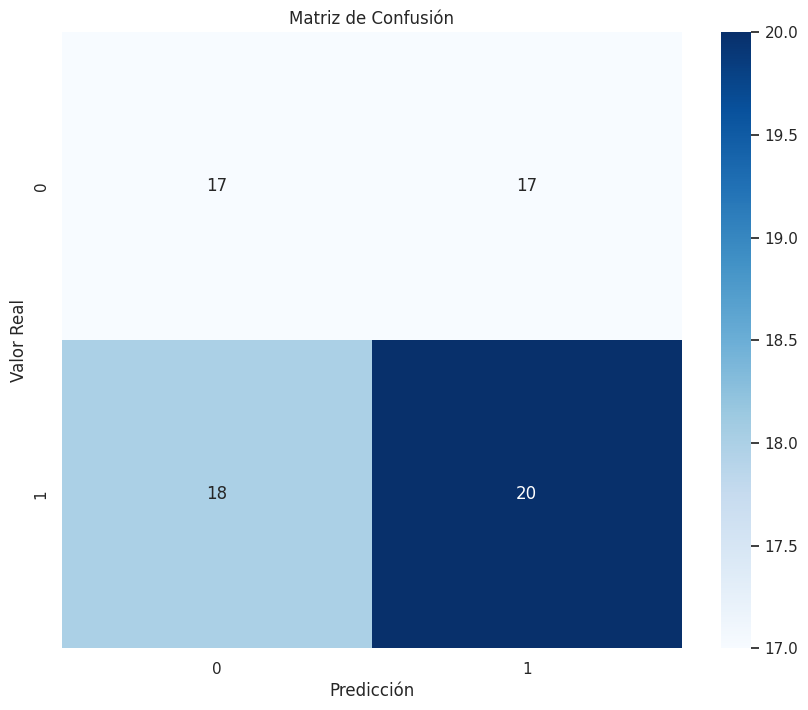


Índices donde hubo errores de predicción: [ 1  6  7  8  9 10 11 13 14 15 16 19 22 27 31 32 34 36 37 39 40 41 43 45
 47 48 54 55 57 58 60 61 63 64 65]
Total de errores: 35 de 72 (48.61%)


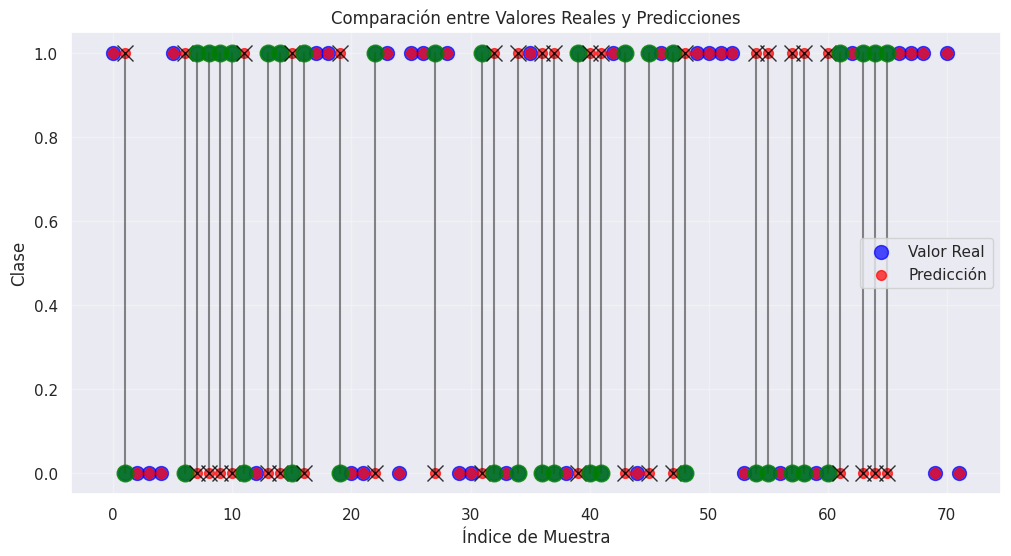


Tabla de comparación:
Índice | Valor Real | Predicción | ¿Correcto?
---------------------------------------------
     0 |          1 |          1 |     ✓     
     1 |          0 |          1 |     ✗     
     2 |          0 |          0 |     ✓     
     3 |          0 |          0 |     ✓     
     4 |          0 |          0 |     ✓     
     5 |          1 |          1 |     ✓     
     6 |          0 |          1 |     ✗     
     7 |          1 |          0 |     ✗     
     8 |          1 |          0 |     ✗     
     9 |          1 |          0 |     ✗     
    10 |          1 |          0 |     ✗     
    11 |          0 |          1 |     ✗     
    12 |          0 |          0 |     ✓     
    13 |          1 |          0 |     ✗     
    14 |          1 |          0 |     ✗     
    15 |          0 |          1 |     ✗     
    16 |          1 |          0 |     ✗     
    17 |          1 |          1 |     ✓     
    18 |          1 |          1 |     ✓     
    19 |   

In [30]:
import joblib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import os

# Primero cargar el modelo
model_path = "../models/best_model.joblib"

try:
    # Cargar el modelo
    loaded_pipeline = joblib.load(model_path)
    print(f"Modelo cargado desde: {model_path}")
    
    # Dividir los datos
    x_train, x_test, y_train, y_test = train_test_split(epochs_data, labels, test_size=0.2, shuffle=True, random_state=42)
    
    # Entrenar el modelo si es necesario (si no está entrenado)
    try:
        # Intentar hacer una predicción simple para comprobar si está entrenado
        loaded_pipeline.predict(x_test[:1])
        print("El modelo ya está entrenado, procediendo a la evaluación...")
    except Exception as e:
        print(f"El modelo necesita entrenamiento: {str(e)}")
        print("Entrenando el modelo...")
        loaded_pipeline.fit(x_train, y_train)
        print("Modelo entrenado correctamente.")
    
    # Obtener predicciones del modelo
    y_pred = loaded_pipeline.predict(x_test)
    
    # Imprimir valores reales y predicciones
    print("Valores reales (y_test):")
    print(y_test)
    print("\nValores predichos (y_pred):")
    print(y_pred)
    
    # Calcular y mostrar precisión del modelo
    accuracy = accuracy_score(y_test, y_pred)
    print(f"\nPrecisión del modelo: {accuracy:.4f}")
    print(f"Score del modelo: {loaded_pipeline.score(x_test, y_test):.4f}")
    
    # Crear informe de clasificación
    print("\nInforme de clasificación:")
    print(classification_report(y_test, y_pred))
    
    # Crear matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    class_names = np.unique(np.concatenate([y_test, y_pred]))
    
    # Visualizar matriz de confusión
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, 
                yticklabels=class_names)
    plt.xlabel('Predicción')
    plt.ylabel('Valor Real')
    plt.title('Matriz de Confusión')
    plt.show()
    
    # Comparar predicciones vs valores reales (visualización)
    plt.figure(figsize=(12, 6))
    plt.scatter(range(len(y_test)), y_test, color='blue', label='Valor Real', alpha=0.7, s=100)
    plt.scatter(range(len(y_pred)), y_pred, color='red', label='Predicción', alpha=0.7, s=50)
    plt.xlabel('Índice de Muestra')
    plt.ylabel('Clase')
    plt.title('Comparación entre Valores Reales y Predicciones')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Mostrar errores en la predicción
    incorrect = np.where(y_test != y_pred)[0]
    if len(incorrect) > 0:
        print(f"\nÍndices donde hubo errores de predicción: {incorrect}")
        print(f"Total de errores: {len(incorrect)} de {len(y_test)} ({len(incorrect)/len(y_test)*100:.2f}%)")
        
        # Resaltar errores en el gráfico
        for idx in incorrect:
            plt.plot([idx, idx], [y_test[idx], y_pred[idx]], 'k-', alpha=0.5)
            plt.plot(idx, y_test[idx], 'o', color='green', alpha=0.8, markersize=12)
            plt.plot(idx, y_pred[idx], 'x', color='black', alpha=0.8, markersize=12)
    
    plt.show()
    
    # Tabla de comparación de valores reales y predicciones
    n_samples = len(y_test)
    comparison_table = np.column_stack((y_test[:n_samples], y_pred[:n_samples]))
    print("\nTabla de comparación:")
    print("Índice | Valor Real | Predicción | ¿Correcto?")
    print("-" * 45)
    for i in range(n_samples):
        is_correct = "✓" if y_test[i] == y_pred[i] else "✗"
        print(f"{i:6d} | {y_test[i]:10} | {y_pred[i]:10} | {is_correct:^10}")
    
    # Guardar el modelo ahora correctamente entrenado
    os.makedirs('../models', exist_ok=True)
    from datetime import datetime
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    save_path = f"../models/evaluated_model.joblib"
    
    joblib.dump(loaded_pipeline, save_path)
    print(f"\nModelo evaluado guardado en: {save_path}")
    
    # Guardar resultados de evaluación en JSON
    import json
    eval_results = {
        'accuracy': float(accuracy),
        'model_path': model_path,
        'timestamp': timestamp,
        'class_names': class_names.tolist(),
        'confusion_matrix': cm.tolist(),
        'n_test_samples': len(y_test),
        'n_errors': len(incorrect),
        'error_rate': float(len(incorrect)/len(y_test))
    }
    
    eval_json_path = f"../models/evaluation_results.json"
    with open(eval_json_path, 'w') as f:
        json.dump(eval_results, f, indent=4)
    
    print(f"Resultados de evaluación guardados en: {eval_json_path}")
    print(f"Accuracy: {accuracy}")

except Exception as e:
    print(f"Error en la evaluación: {str(e)}")


## EVALUATION

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import mne
from mne import pick_types, Epochs
from mne.datasets import eegbci
from mne.channels import make_standard_montage
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd
import seaborn as sns
import random
from sklearn.model_selection import train_test_split

# First, make sure the model is properly fitted
# Re-fit the models_pipeline with the training data
x_train, x_test, y_train, y_test = train_test_split(epochs_data, labels, test_size=0.2, shuffle=True, random_state=42)
print("Fitting the model pipeline...")
models_pipeline.fit(x_train, y_train)
print("Model fitted successfully!")

# Test the model on the test data to verify it works
test_accuracy = models_pipeline.score(x_test, y_test)
print(f"Test accuracy: {test_accuracy:.4f}")

# Function to process a subject using a single random run of the paradigm
def process_subject_one_random_run(subject_id, possible_runs, tmin, tmax):
    """
    Process a subject from the EEGBCI dataset using a single randomly chosen run.
    
    Parameters:
    - subject_id: Subject ID to process
    - possible_runs: List of possible runs (one will be randomly chosen)
    - tmin, tmax: Time window for epochs
    
    Returns:
    - Processed epoch data, labels, and selected run
    """
    # Select a random run from the possible ones
    selected_run = random.choice(possible_runs)
    
    print(f"Processing subject {subject_id} with run: {selected_run}")
    
    # Download data only for the selected run
    raw_fnames = eegbci.load_data(subject_id, [selected_run])
    raw = mne.io.read_raw_edf(raw_fnames[0], preload=True)
    
    # Apply the same preprocessing as used in training
    picks = pick_types(raw.info, meg=False, eeg=True, stim=False, eog=False, exclude='bads')
    eegbci.standardize(raw)  # Standardize channel names
    montage = make_standard_montage('standard_1005')
    raw.set_montage(montage)
    raw.filter(8., 40., fir_design='firwin', skip_by_annotation='edge')
    
    # Extract events
    events, event_id = mne.events_from_annotations(raw)
    
    print(f"Events found: {event_id}")
    
    # Determine the correct event_id based on the paradigm
    if selected_run in [5, 9, 13]:  # Motor execution: hands vs feet
        # For this paradigm, we typically use events T1 and T2
        relevant_events = {}
        for key, value in event_id.items():
            if key in ['T1', 'T2'] or key == '1' or key == '2':
                relevant_events[key] = value
        
        print(f"Relevant events for the paradigm: {relevant_events}")
    
    # Create epochs with the relevant events
    epochs = Epochs(raw, events, relevant_events, tmin, tmax, proj=True, 
                   picks=picks, baseline=None, preload=True)
    
    # Get data and labels
    epochs_data = epochs.get_data().astype(np.float64)
    
    # Normalize labels to 0 and 1
    # Find the unique event codes and map them to 0, 1
    unique_events = sorted(list(relevant_events.values()))
    label_map = {unique_events[0]: 0, unique_events[1]: 1}
    
    # Map event codes to 0, 1
    labels = np.array([label_map[event] for event in epochs.events[:, -1]])
    
    return epochs_data, labels, selected_run

# Determinar los runs del paradigma usado en el entrenamiento
try:
    runs_for_model = run_experiments  # Los runs usados para entrenar el modelo
    print(f"Usando el paradigma de entrenamiento con runs: {runs_for_model}")
except NameError:
    # Si no está definida, asumir Motor execution: hands vs feet
    runs_for_model = [5, 9, 13]  # Por defecto: Motor execution: hands vs feet
    print(f"Variable 'run_experiments' no encontrada. Asumiendo paradigma con runs: {runs_for_model}")

# Identificar qué paradigma corresponde a estos runs
experiment_groups = {
    'Motor execution left vs right': [3, 7, 11],
    'Motor imagery left vs right': [4, 8, 12],
    'Motor execution hands vs feet': [5, 9, 13],
    'Motor imagery hands vs feet': [6, 10, 14]
}

experiment_name = "Desconocido"
for name, runs in experiment_groups.items():
    if set(runs_for_model) == set(runs):
        experiment_name = name
        break

print(f"Tipo de experimento identificado: {experiment_name}")

# Obtener sujetos disponibles en el dataset EEGBCI
all_subjects = list(range(1, 110))  # El dataset EEGBCI tiene 109 sujetos

# Filtrar los sujetos ya utilizados
try:
    used_subjects = subjects  # Intentar usar 'subjects' si está definido
    print(f"Sujetos ya utilizados: {used_subjects}")
except NameError:
    used_subjects = [1, 2, 3]  # Asumir algunos sujetos predeterminados
    print(f"Variable 'subjects' no encontrada, asumiendo que se usaron los sujetos: {used_subjects}")

available_subjects = [s for s in all_subjects if s not in used_subjects]

# Seleccionar 6 sujetos aleatoriamente sin repetición
# test_subjects = random.sample(available_subjects, 6)
# test_subjects = [1, 2, 3, 1, 2, 3]
test_subjects = random.sample(subjects, 6)
test_subjects.sort()  # Ordenar por claridad
print(f"Sujetos seleccionados para evaluación: {test_subjects}")

# Almacenar resultados
results = {}

# Procesar cada sujeto y evaluar el modelo
for subject in test_subjects:
    try:
        # Procesar el sujeto con un run aleatorio del mismo paradigma
        X, y, selected_run = process_subject_one_random_run(subject, runs_for_model, tmin, tmax)
        
        # Verificar si se encontraron épocas
        if len(X) == 0:
            print(f"No se encontraron épocas válidas para el sujeto {subject}, run {selected_run}")
            continue
        
        print(f"Forma de X: {X.shape}, Clases en y: {np.unique(y)}")
        
        # Predecir con el modelo entrenado
        y_pred = models_pipeline.predict(X)
        
        # Calcular métricas
        accuracy = accuracy_score(y, y_pred)
        conf_matrix = confusion_matrix(y, y_pred)
        report = classification_report(y, y_pred, output_dict=True)
        
        # Guardar resultados
        results[subject] = {
            'accuracy': accuracy,
            'conf_matrix': conf_matrix,
            'report': report,
            'n_trials': len(y),
            'run': selected_run,
            'predictions': y_pred,  # Store predictions
            'actual': y            # Store actual values
        }
        
        print(f"Sujeto {subject} (run {selected_run}): Accuracy = {accuracy:.4f} ({len(y)} ensayos)")
        
        # Print detailed comparison table for this subject
        print("\nTabla de comparación:")
        print("Índice | Valor Real | Predicción | ¿Correcto?")
        print("-" * 45)
        for i in range(len(y)):
            is_correct = "✓" if y[i] == y_pred[i] else "✗"
            print(f"{i:6d} | {y[i]:10d} | {y_pred[i]:10d} | {is_correct:^10}")
        
    except Exception as e:
        print(f"Error procesando sujeto {subject}: {str(e)}")
        # Imprimir más detalles del error para depuración
        import traceback
        traceback.print_exc()

# Calcular y mostrar el promedio de accuracy entre todos los sujetos
if results:
    # Calcular promedio ponderado por el número de ensayos
    total_trials = sum(res['n_trials'] for res in results.values())
    weighted_avg = sum(res['accuracy'] * res['n_trials'] for res in results.values()) / total_trials
    
    # Calcular promedio simple
    simple_avg = sum(res['accuracy'] for res in results.values()) / len(results)
    
    print(f"\nPromedio de accuracy (simple): {simple_avg:.4f}")
    print(f"Promedio de accuracy (ponderado por ensayos): {weighted_avg:.4f}")
    
    # Crear DataFrame para visualización
    df_results = pd.DataFrame({
        'Sujeto': list(results.keys()),
        'Run': [res['run'] for res in results.values()],
        'Accuracy': [res['accuracy'] for res in results.values()],
        'Num. Ensayos': [res['n_trials'] for res in results.values()]
    })
    
    # Visualizar resultados
    plt.figure(figsize=(16, 12))
    
    # 1. Gráfico de barras de accuracy por sujeto
    plt.subplot(2, 1, 1)
    bar_colors = ['skyblue' if run == runs_for_model[0] else 
                 'lightgreen' if run == runs_for_model[1] else 'salmon' 
                 for run in df_results['Run']]
    
    bars = plt.bar(df_results['Sujeto'].astype(str), df_results['Accuracy'], 
                  color=bar_colors, alpha=0.7)
    
    # Añadir línea de promedio
    plt.axhline(y=simple_avg, color='r', linestyle='-', label=f'Promedio: {simple_avg:.4f}')
    
    # Añadir etiquetas de valores y runs
    for i, bar in enumerate(bars):
        height = bar.get_height()
        run = df_results['Run'].iloc[i]
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.4f}', ha='center', va='bottom')
        plt.text(bar.get_x() + bar.get_width()/2., height/2,
                f'Run {run}', ha='center', va='center', 
                color='black', fontweight='bold')
    
    plt.xlabel('Sujeto')
    plt.ylabel('Accuracy')
    plt.title(f'Accuracy por Sujeto - Experimento: {experiment_name}')
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    
    # 2. Heatmap de matrices de confusión
    plt.subplot(2, 2, 3)
    avg_conf_matrix = sum(res['conf_matrix'] for res in results.values()) / len(results)
    sns.heatmap(avg_conf_matrix, annot=True, fmt='.1f', cmap='Blues', 
                xticklabels=list(range(len(avg_conf_matrix))),
                yticklabels=list(range(len(avg_conf_matrix))))
    plt.title('Matriz de Confusión Promedio')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    
    # 3. Gráfico de accuracy por run
    plt.subplot(2, 2, 4)
    
    # Agrupar resultados por run
    run_data = df_results.groupby('Run').agg({
        'Accuracy': ['mean', 'std', 'count'],
        'Num. Ensayos': 'mean'
    })
    
    run_labels = [f'Run {r}' for r in run_data.index]
    
    # Crear barras para cada run
    run_bars = plt.bar(run_labels, run_data[('Accuracy', 'mean')], 
                      yerr=run_data[('Accuracy', 'std')], capsize=10,
                      color=['skyblue', 'lightgreen', 'salmon'][:len(run_data)], 
                      alpha=0.7)
    
    # Añadir etiquetas
    for i, bar in enumerate(run_bars):
        count = run_data[('Accuracy', 'count')].iloc[i]
        mean = run_data[('Accuracy', 'mean')].iloc[i]
        plt.text(bar.get_x() + bar.get_width()/2., mean + 0.02,
                f'{mean:.4f}', ha='center', va='bottom')
        plt.text(bar.get_x() + bar.get_width()/2., mean/2,
                f'n={count}', ha='center', va='center', 
                color='black', fontweight='bold')
    
    plt.xlabel('Run')
    plt.ylabel('Accuracy Promedio')
    plt.title('Accuracy Promedio por Run')
    plt.ylim(0, 1)
    plt.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.suptitle(f'Evaluación de Modelo en {len(results)} Nuevos Sujetos - {experiment_name}', fontsize=16, y=1.02)
    plt.show()
    
    # For each subject, show a tabular comparison
    for subject, result in results.items():
        y = result['actual']
        y_pred = result['predictions']
        
        print(f"\n\nComparación detallada para Sujeto {subject} (Run {result['run']})")
        print("Tabla de comparación:")
        print("Índice | Valor Real | Predicción | ¿Correcto?")
        print("-" * 45)
        
        for i in range(len(y)):
            is_correct = "✓" if y[i] == y_pred[i] else "✗"
            print(f"{i:6d} | {int(y[i]):10d} | {int(y_pred[i]):10d} | {is_correct:^10}")
        
        print(f"\nResumen: {result['accuracy']*100:.2f}% correcto ({int(sum(y == y_pred))} de {len(y)})")
    
    # Crear tabla de resultados detallada
    plt.figure(figsize=(12, 6))
    table_data = [
        [f"Sujeto {s}", r['run'], f"{r['accuracy']:.4f}", r['n_trials']] 
        for s, r in results.items()
    ]
    table_data.append(['Promedio', '', f"{simple_avg:.4f}", f"{total_trials/len(results):.1f}"])
    
    plt.axis('off')
    table = plt.table(
        cellText=table_data,
        colLabels=['Sujeto', 'Run', 'Accuracy', 'Núm. Ensayos'],
        loc='center',
        cellLoc='center',
        colWidths=[0.15, 0.15, 0.15, 0.15]
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.5)
    
    # Resaltar la fila del promedio
    for (i, j), cell in table.get_celld().items():
        if i == len(table_data) - 1:  # La última fila (promedio)
            cell.set_facecolor('lightgray')
            cell.set_text_props(weight='bold')
    
    plt.title(f'Informe Final de Predicciones - {experiment_name}', fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()
    
    # Generar informe de texto detallado
    print("\n" + "="*80)
    print(f"{'INFORME FINAL DE PREDICCIONES':^80}")
    print(f"{'Experimento: ' + experiment_name:^80}")
    print("="*80)
    print(f"Número total de sujetos evaluados: {len(results)}")
    print(f"Promedio de accuracy simple: {simple_avg:.4f}")
    print(f"Promedio de accuracy ponderado: {weighted_avg:.4f}")
    print("\nResultados detallados por sujeto:")
    print("-"*80)
    
    # Formatear tabla para impresión en consola (fixed formatting)
    print(f"{'Sujeto':<10}{'Run':<10}{'Accuracy':<15}{'Núm. Ensayos':<15}")
    print("-"*80)
    for subject, res in results.items():
        print(f"{subject:<10}{res['run']:<10}{res['accuracy']:.4f}{res['n_trials']:<15}")
    print("-"*80)
    print(f"{'Promedio':<10}{'':<10}{simple_avg:.4f}{int(total_trials/len(results)):<15}")
    print("="*80)
    
    # Análisis por run
    print("\nAnálisis por run:")
    for run in runs_for_model:
        run_results = [res['accuracy'] for subj, res in results.items() if res['run'] == run]
        if run_results:
            print(f"Run {run}: {np.mean(run_results):.4f} (promedio de {len(run_results)} sujetos)")
        else:
            print(f"Run {run}: No hay datos")
    
    # Guardar resultados en un archivo CSV
    df_results['Experimento'] = experiment_name
    df_results.to_csv('../models/resultados_nuevos_sujetos_run_aleatorio.csv', index=False)
    
    print("\nResultados guardados en 'resultados_nuevos_sujetos_run_aleatorio.csv'")
else:
    print("No se obtuvieron resultados para analizar.")


Fitting the model pipeline...


NameError: name 'models_pipeline' is not defined